<a href="https://colab.research.google.com/github/D2718281828nis/class-regression_model/blob/main/smirnov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install catboost scikit-learn matplotlib seaborn scipy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


# Новый раздел

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor

3. Загрузка данных

In [3]:
datalink = 'https://raw.githubusercontent.com/cuttingmind/regression_model/refs/heads/main/insurance.csv'
df = pd.read_csv(datalink)
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


4. Информация о датасете

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


5. Статистика по числовым колонкам

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# Новый раздел

6. One-Hot Encoding категориальных признаков

In [6]:
df_encode = pd.get_dummies(df, columns=["sex", "region", "smoker"])
# преобразует категориальные колонки в бинарные (0/1)
df_encode = df_encode.drop('sex_female', axis=1)
df_encode = df_encode.drop('smoker_no', axis=1)
df_encode.head()

,age,bmi,children,charges,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_yes
0,19,27.900,0,16884.92400,False,False,False,False,True,True
1,18,33.770,1,1725.55230,True,False,False,True,False,False
2,28,33.000,3,4449.46200,True,False,False,True,False,False
3,33,22.705,0,21984.47061,True,False,True,False,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False,False


7. Гистограммы распределений

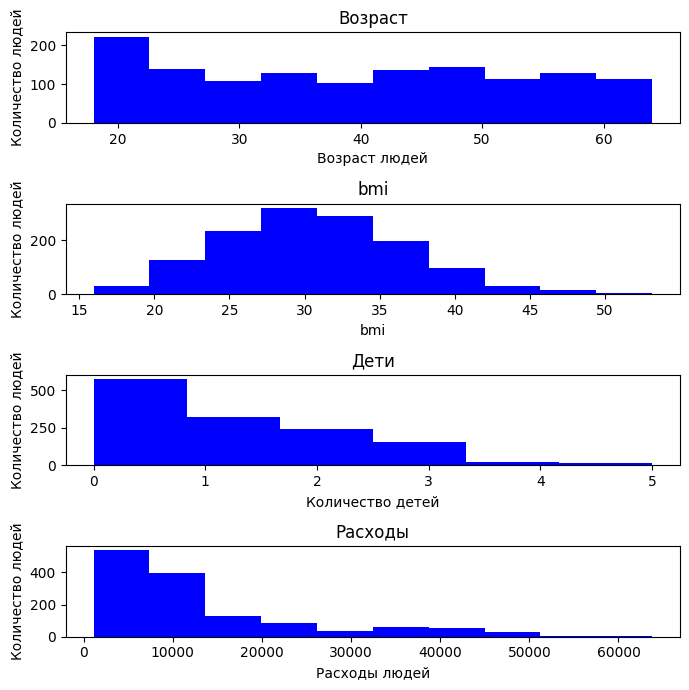

In [7]:
colors = ['blue', 'green', 'red', 'purple', 'orange']
fig, axes = plt.subplots(nrows=4, ncols=1,figsize=(7, 7))
axes = axes.flatten()
axes[0].hist(df["age"], bins=10, color=colors[0])
axes[0].set_title('Возраст')
axes[0].set_xlabel("Возраст людей")
axes[0].set_ylabel("Количество людей")

axes[1].hist(df["bmi"], bins=10, color=colors[0])
axes[1].set_title('bmi')
axes[1].set_xlabel("bmi")
axes[1].set_ylabel("Количество людей")

axes[2].hist(df["children"], bins=6, color=colors[0])
axes[2].set_title('Дети')
axes[2].set_xlabel("Количество детей")
axes[2].set_ylabel("Количество людей")

axes[3].hist(df["charges"], bins=10, color=colors[0])
axes[3].set_title('Расходы')
axes[3].set_xlabel("Расходы людей")
axes[3].set_ylabel("Количество людей")
plt.subplots_adjust(hspace=0.6)
plt.tight_layout()

8. Корреляция Спирмана с целевой переменной

In [8]:
spearman_corr = df_encode.corr(method='spearman')
# метод DataFrame .corr() вычисляет матрицу
# корреляций между всеми числовыми колонками
spearman_corr['charges'].sort_values(ascending=False)
#  извлекает столбец матрицы, соответствующий целевой переменной

,charges
charges,1.000000
smoker_yes,0.663460
age,0.534392
children,0.133339
bmi,0.119396
region_northeast,0.046109
region_southeast,0.017275
sex_male,0.009490
region_northwest,-0.021634
region_southwest,-0.042354


9. Boxplot'ы по категориальным признакам

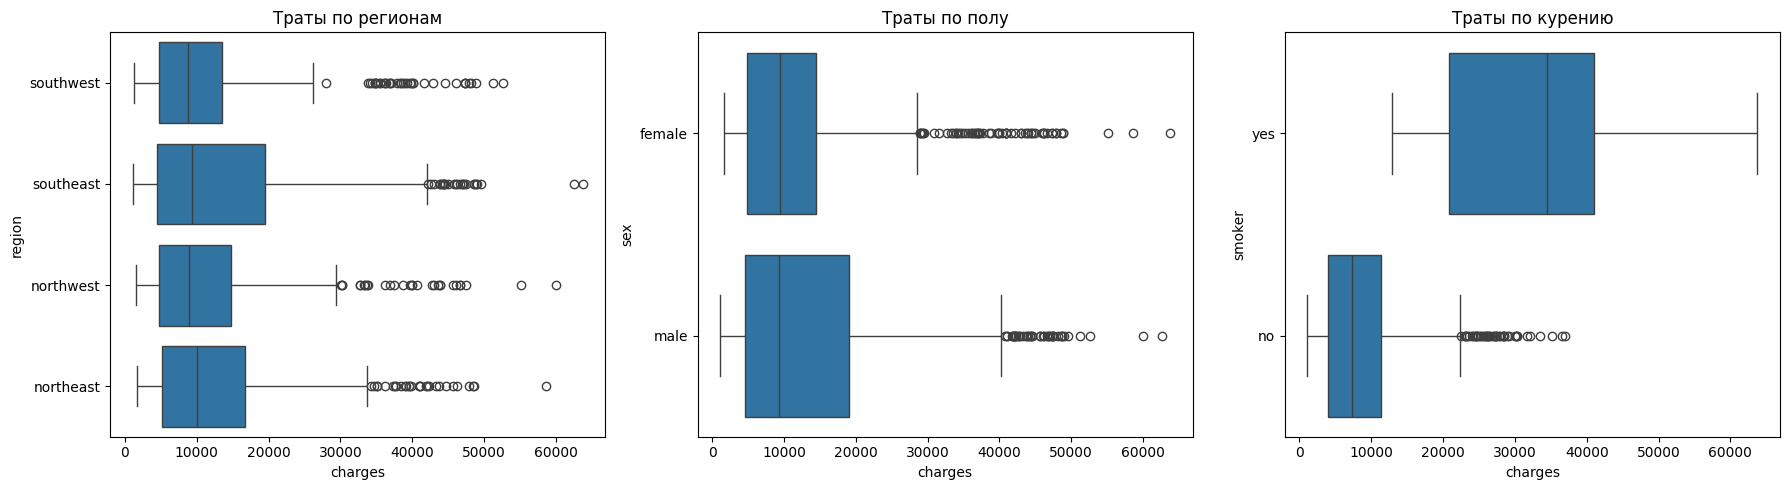

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y="region", x="charges", data=df, ax=axes[0])
axes[0].set_title("Траты по регионам")

sns.boxplot(y="sex", x="charges", data=df, ax=axes[1])
axes[1].set_title("Траты по полу")

sns.boxplot(y="smoker", x="charges", data=df, ax=axes[2])
axes[2].set_title("Траты по курению")

plt.tight_layout()
plt.show()

10. Scatter plot — возраст vs расходы с учётом курения

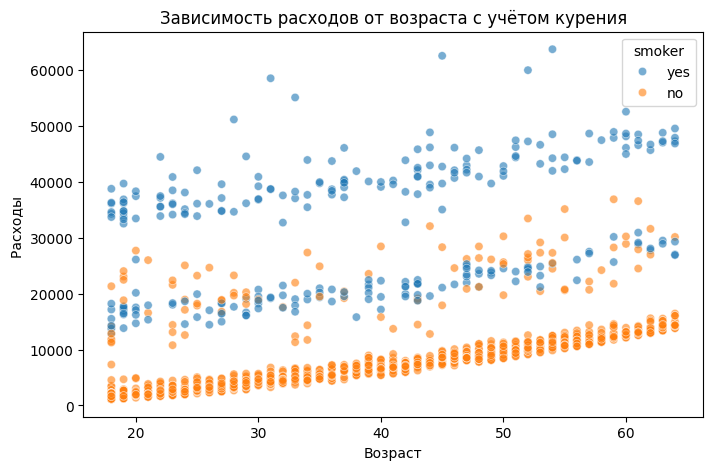

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="age", y="charges", hue="smoker", data=df, alpha=0.6)
plt.title("Зависимость расходов от возраста с учётом курения")
plt.xlabel("Возраст")
plt.ylabel("Расходы ")
plt.show()

11. Создание группы BMI

In [11]:
df['bmi_group'] = pd.cut(df['bmi'], bins=[0, 25, 30, 100],
                         labels=['Норма', 'Избыточный вес', 'Ожирение'])
# df['bmi_group'] = ... — создаёт новую колонку

12. FacetGrid — scatter plot по курению и BMI

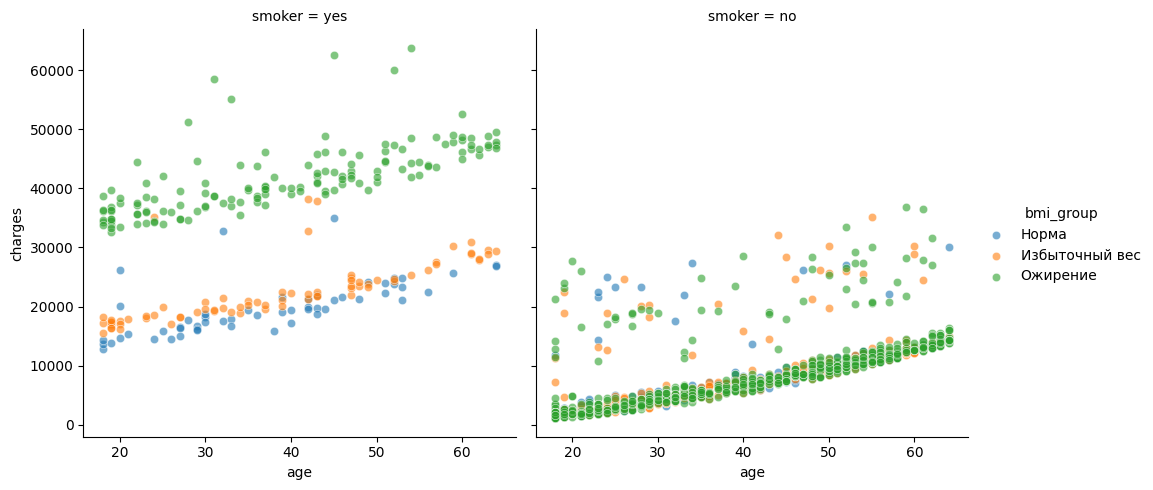

In [12]:
g = sns.FacetGrid(df, col="smoker", hue="bmi_group", height=5)
g.map(sns.scatterplot, "age", "charges", alpha=0.6).add_legend()
plt.show()

13. Средние расходы по количеству детей

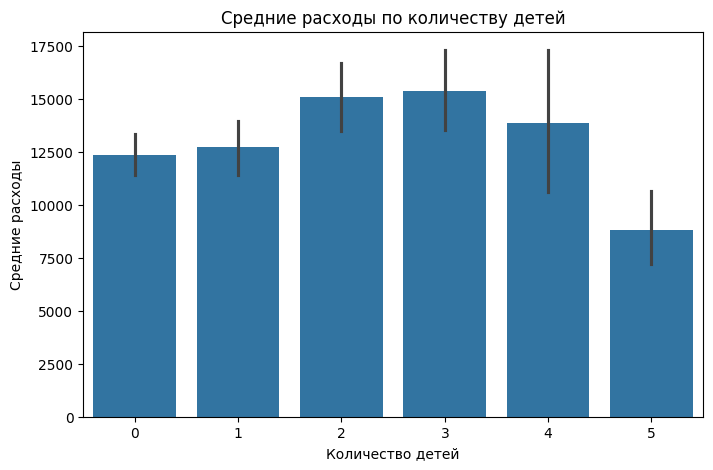

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(x="children", y="charges", data=df, estimator=lambda x: x.mean())
plt.title("Средние расходы по количеству детей")
plt.xlabel("Количество детей")
plt.ylabel("Средние расходы")
plt.show()

14. Тепловая карта корреляций

<Axes: >

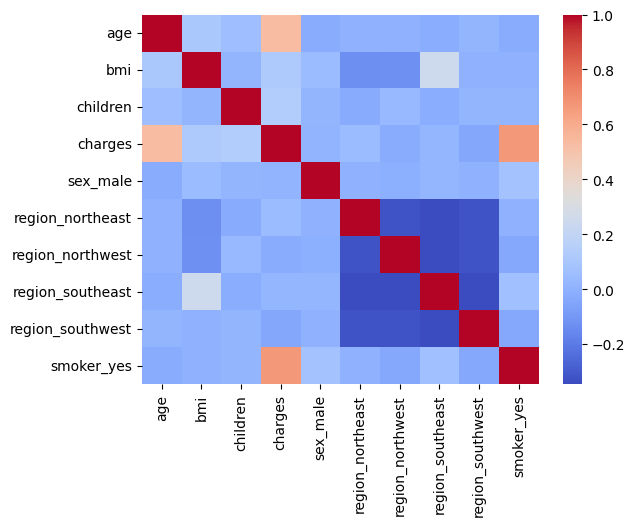

In [14]:
sns.heatmap(df_encode.corr(method='spearman'), cmap="coolwarm", annot=False)

15. Создание таблицы результатов

In [15]:
Result_model = pd.DataFrame(columns=["Model", "MAE", "RMSE", "R2"])
# pd.DataFrame создания пустой таблицы

# Result_model — переменная, в которую
# будут добавляться результаты обучения моделей

16. Подготовка данных для обучения

In [16]:
X = df_encode.drop("charges", axis=1)
# создаёт матрицу признаков
# X — обозначает матрицу признаков
# y — обозначает то, что нужно предсказать
y = df_encode["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# случайно разбивает данные на обучающую и тестовую выборки,

17. Модель Lasso Regression

In [17]:
lasso = Lasso(alpha=0.5) # Параметр alpha=0.5 — сила регуляризации

lasso.fit(X_train, y_train) # обучает модель на тренировочных данных

y_pred_lasso = lasso.predict(X_test) # метод .predict() делает предсказания на тестовых даннх

mae_lasso = mean_absolute_error(y_test, y_pred_lasso) # считает MAE (средняя абсолютная ошибка)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso)) # считает RMSE (корень из MSE)
r2_lasso = r2_score(y_test, y_pred_lasso) # считает R² (коэффициент детерминации)

print("Lasso Regression")
print("MAE:", mae_lasso)
print("RMSE:", rmse_lasso)
print("R²:", r2_lasso)

coef_lasso = pd.DataFrame({ # создаёт DataFrame с двумя колонками
    "Feature": X.columns,
    "Coefficient": lasso.coef_
}).sort_values(by="Coefficient", ascending=False) # сортирует по убыванию коэффициентов (самые влиятельные признаки сверху)

print("Коэффициенты Lasso:")
print(coef_lasso)

Lasso Regression
MAE: 4195.228376125622
RMSE: 6052.947089574029
R²: 0.7545404110605294
Коэффициенты Lasso:
            Feature   Coefficient
8        smoker_yes  23784.105832
4  region_northeast    928.681101
5  region_northwest    563.767153
2          children    423.032365
1               bmi    364.077724
0               age    255.790472
3          sex_male    -37.094668
7  region_southwest    -52.564653
6  region_southeast   -167.022142


18. Добавление метрик Lasso в таблицу

In [18]:
row = pd.DataFrame({
    "Model": ["Lasso"],
    "MAE": [mae_lasso],
    "RMSE": [rmse_lasso],
    "R2": [r2_lasso]
})
# row = pd.DataFrame({...}) — создаёт DataFrame из одной строки с
# результатами Lasso. Ключи словаря — названия колонок,
# значения — списки с одним элементом.

Result_model = pd.concat([Result_model, row])

/tmp/ipykernel_2842/2208027307.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Result_model = pd.concat([Result_model, row])


19. Модель Random Forest

In [19]:
rf = RandomForestRegressor( # создаёт модель Случайный лес
    n_estimators=100,       # количество деревьев
    max_depth=4,            # максимальная глубина каждого дерева
    min_samples_split = 20, # минимальное число образцов, необходимое для разбиения узла
    min_samples_leaf = 20   # минимальное число образцов в листе
)

rf.fit(X_train, y_train) # обучает лес

y_pred_rf = rf.predict(X_test) # предсказания на тесте

mae_rf = mean_absolute_error(y_test, y_pred_rf) # то же что и выше
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_ # rf.feature_importances_ — атрибут модели, содержащий важность признаков
}).sort_values(by="Importance", ascending=False)

print("\nВажность признаков:")
print(importances)

Random Forest
MAE: 2516.681492250032
RMSE: 4488.845095121069
R²: 0.865005683406582

Важность признаков:
            Feature  Importance
8        smoker_yes    0.711389
1               bmi    0.161607
0               age    0.121863
2          children    0.004508
4  region_northeast    0.000307
3          sex_male    0.000214
6  region_southeast    0.000054
7  region_southwest    0.000044
5  region_northwest    0.000014


20. Добавление метрик Random Forest в таблицу

In [20]:
row = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE": [mae_rf],
    "RMSE": [rmse_rf],
    "R2": [r2_rf]
})
# так же как и выше но для random forest

Result_model = pd.concat([Result_model, row])

21. CatBoost Regressor (версия 1)

In [21]:
cat_features = ["smoker", "sex", "region", "bmi_group"]
#  список названий категориальных признаков
feature_cols = [c for c in df.columns if c not in ["charges"]]
# проходит по всем колонкам df и оставляет только те,
# что не равны charges

cat = CatBoostRegressor( # создаёт модель
    iterations=1000,      # число итераций бустинга
    depth=6,              # глубина деревьев
    learning_rate=0.01,   # скорость обучения
    verbose=100,          # выводить прогресс каждые 100 итераций,
    random_state=42       # фиксирует случайность для воспроизводимости.
)


X = df[feature_cols] # матрица признаков из исходного df
y = df["charges"]    # целевая переменная

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# разбиение 70/30

cat.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test), verbose=100)
# обучение

y_pred_cat = cat.predict(X_test)
# предсказания

mae_cat1 = mean_absolute_error(y_test, y_pred_cat)
rmse_cat1 = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2_cat1 = r2_score(y_test, y_pred_cat)

feature_importance = cat.get_feature_importance(prettified=True)
print(feature_importance)
# метод CatBoost, возвращающий важность признаков в виде
# таблицы (DataFrame).

print("CatBoost")
print("MAE:", mae_cat1)
print("RMSE:", rmse_cat1)
print("R²:", r2_cat1)

0:	learn: 12012.7623953	test: 12022.6832870	best: 12022.6832870 (0)	total: 54.7ms	remaining: 54.6s
100:	learn: 6588.9182958	test: 6428.5924879	best: 6428.5924879 (100)	total: 151ms	remaining: 1.34s
200:	learn: 4994.4292634	test: 4771.7373188	best: 4771.7373188 (200)	total: 237ms	remaining: 942ms
300:	learn: 4563.0127217	test: 4375.7611480	best: 4375.7611480 (300)	total: 332ms	remaining: 771ms
400:	learn: 4390.0318710	test: 4271.3894397	best: 4271.3894397 (400)	total: 432ms	remaining: 646ms
500:	learn: 4302.3381034	test: 4238.5728584	best: 4238.5728584 (500)	total: 530ms	remaining: 528ms
600:	learn: 4239.0356903	test: 4226.4129097	best: 4225.3109797 (591)	total: 629ms	remaining: 418ms
700:	learn: 4178.2073348	test: 4218.5684431	best: 4218.2519708 (694)	total: 732ms	remaining: 312ms
800:	learn: 4125.7600669	test: 4218.0175076	best: 4217.5800056 (794)	total: 832ms	remaining: 207ms
900:	learn: 4074.8128408	test: 4221.1859298	best: 4217.5800056 (794)	total: 946ms	remaining: 104ms
999:	learn

22. Добавление метрик CatBoost v1 в таблицу

In [22]:
row = pd.DataFrame({
    "Model": ["CatBoostRegressor 1ver"],
    "MAE": [mae_cat1],
    "RMSE": [rmse_cat1],
    "R2": [r2_cat1]
})
# так же как и выше но для CatBoost v1
Result_model = pd.concat([Result_model, row])

23. Подбор гиперпараметров CatBoost через RandomizedSearchCV

In [23]:
scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}
# словарь метрик для оценки

cat_base = CatBoostRegressor(
    verbose=False,        # не выводить логи обучения
    random_state=42,
    # task_type="GPU",    # использовать видеокарту для ускорения
    # devices="0"         # использовать GPU номер 0
)
# базовая модель для поиска

param_distributions = {
    "iterations": randint(300, 1000), # случайное целое от 300 до 1000
    "depth": randint(4, 8),
    "learning_rate": loguniform(1e-3, 3e-1),
    "l2_leaf_reg": loguniform(1e-2, 1e2),
    "bagging_temperature": uniform(0.0, 1.0), # равномерное распределение от 0 до 1,
    "random_strength": loguniform(1e-3, 10),
    "grow_policy": ["SymmetricTree", "Depthwise"],
    "border_count": randint(32, 128),
    "leaf_estimation_iterations": randint(1, 3)
}
# словарь: какие параметры и из какого распределения случайно выбирать

rs = RandomizedSearchCV(    # создаёт объект случайного поиска
    estimator=cat_base,                       # модель, которую настраиваем
    param_distributions=param_distributions,  # пространство параметров
    n_iter=20,                                # проверить 20 случайных комбинаций
    scoring=scoring,                          # оценивать по 3 метрикам
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    # данные делятся на 5 частей, по очереди каждая используется как тест
    n_jobs=1,                                 # использовать 1 поток
    random_state=42,
    refit=False    # не переобучать лучшую модель автоматически
)

rs.fit(X_train, y_train, cat_features=cat_features) # запускает поиск

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=False),
                   n_iter=20, n_jobs=1,
                   param_distributions={'bagging_temperature': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x786e84d04680>,
                                        'border_count': <scipy.stats._distn_infrastructure.rv_discret...
                                        'leaf_estimation_iterations': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x786e84d04830>,
                                        'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x786e84d04470>,
                                        'random_strength': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x786e902980b0>},
                   random_state=42, refit=False,
                   scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2',
                            'rmse': 'neg_root_mean_squared_error'})

24. Выбор лучших гиперпараметров

In [24]:
cv = rs.cv_results_
# атрибут RandomizedSearchCV, содержащий словарь с
# результатами всех экспериментов

best_idx = np.argmax(cv["mean_test_r2"])
# массив средних значений R²

best_params = cv["params"][best_idx]
# функция NumPy, возвращающая индекс
# максимального элемента (лучшая R²)

print("Лучшая конфигурация по r2:", best_params)

Лучшая конфигурация по r2: {'bagging_temperature': np.float64(0.3745401188473625), 'border_count': 124, 'depth': 6, 'grow_policy': 'SymmetricTree', 'iterations': 371, 'l2_leaf_reg': np.float64(2.481040974867813), 'leaf_estimation_iterations': 1, 'learning_rate': np.float64(0.012716915576128595), 'random_strength': np.float64(0.002511306167739001)}


25. Обучение CatBoost с лучшими параметрами (версия 2)

In [25]:
best_cat = CatBoostRegressor(
    verbose=False,
    random_state=42,
    # task_type="GPU",
    # devices="0",
    **best_params)

best_cat.fit(X_train, y_train, cat_features=cat_features)

y_pred = best_cat.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


fi = best_cat.get_feature_importance(prettified=True)
print(fi)

MAE: 2508.6308844677774
RMSE: 4255.325794093027
R²: 0.8765020761295006
  Feature Id  Importances
0     smoker    78.303392
1        bmi    12.630332
2        age     6.509039
3   children     1.385152
4     region     0.492377
5  bmi_group     0.458960
6        sex     0.220747


26. Добавление метрик CatBoost v2 в таблицу

In [26]:
row = pd.DataFrame({
    "Model": ["CatBoostRegressor 2ver"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2]
})
# Добавляет строку с метриками CatBoost v2.
Result_model = pd.concat([Result_model, row])

27. Feature Engineering — создание новых признаков

In [29]:
#df = pd.read_csv("insurance.csv")

# перезагружает датасет с нуля
df["age_decade"] = (df["age"] // 10).astype(int).astype("category")
df["children_bucket"] = pd.cut(df["children"], [-1,0,2,99], labels=["0","1-2","3+"])
df["obesity_class"] = pd.cut(df["bmi"],
    [0,18.5,25,30,35,40,1e3], labels=["Under","Normal","Over","Ob1","Ob2", "Ob3"])

28. CatBoost с новыми признаками (версия 3)

In [31]:
cat_features = ["smoker", "sex", "region", "obesity_class", "age_decade", "children_bucket", "bmi_group"]
feature_cols = [c for c in df.columns if c not in ["charges"]]

cat = CatBoostRegressor(
    iterations=2000,
    depth=6,
    learning_rate=0.01,
    verbose=100, random_state=42
)

X = df[feature_cols]
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test), verbose=100)

y_pred_cat = cat.predict(X_test)

mae_cat = mean_absolute_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2_cat = r2_score(y_test, y_pred_cat)

feature_importance = cat.get_feature_importance(prettified=True)
print(feature_importance)

print("CatBoost")
print("MAE:", mae_cat)
print("RMSE:", rmse_cat)
print("R²:", r2_cat)

0:	learn: 11926.9907359	test: 12373.1424654	best: 12373.1424654 (0)	total: 5.17ms	remaining: 10.3s
100:	learn: 6549.1240532	test: 6680.9138776	best: 6680.9138776 (100)	total: 385ms	remaining: 7.24s
200:	learn: 4959.8259126	test: 4914.7937437	best: 4914.7937437 (200)	total: 735ms	remaining: 6.58s
300:	learn: 4531.6310778	test: 4441.0541910	best: 4441.0541910 (300)	total: 1.08s	remaining: 6.12s
400:	learn: 4390.3516406	test: 4324.4047568	best: 4324.4047568 (400)	total: 1.46s	remaining: 5.81s
500:	learn: 4301.8230221	test: 4282.3336772	best: 4282.3336772 (500)	total: 1.84s	remaining: 5.52s
600:	learn: 4230.7647398	test: 4258.7006729	best: 4258.6864332 (599)	total: 2.63s	remaining: 6.12s
700:	learn: 4166.1077238	test: 4247.0768939	best: 4247.0768939 (700)	total: 3.24s	remaining: 6s
800:	learn: 4106.1415200	test: 4238.1175402	best: 4238.1175402 (800)	total: 3.56s	remaining: 5.33s
900:	learn: 4045.2334922	test: 4228.7058552	best: 4228.3495349 (896)	total: 3.78s	remaining: 4.61s
1000:	learn: 

29. Добавление метрик CatBoost v3 в таблицу

In [32]:
row = pd.DataFrame({
    "Model": ["CatBoostRegressor 3ver"],
    "MAE": [mae_cat],
    "RMSE": [rmse_cat],
    "R2": [r2_cat]
})

Result_model = pd.concat([Result_model, row])

30. CatBoost v4 — лучшие параметры + новые признаки

In [34]:
cat_features = ["smoker", "sex", "region", "obesity_class", "age_decade", "children_bucket", "bmi_group"]
feature_cols = [c for c in df.columns if c not in ["charges"]]

best_cat = CatBoostRegressor(
    verbose=False,
    random_state=42,
    # task_type="GPU",
    # devices="0",
    **best_params
)

X = df[feature_cols]
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

cat.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test), verbose=100)
# ?

y_pred_cat = cat.predict(X_test)

mae_cat = mean_absolute_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2_cat = r2_score(y_test, y_pred_cat)

feature_importance = cat.get_feature_importance(prettified=True)
print(feature_importance)

print("CatBoost")
print("MAE:", mae_cat)
print("RMSE:", rmse_cat)
print("R²:", r2_cat)

0:	learn: 11967.3194416	test: 12238.9619643	best: 12238.9619643 (0)	total: 4.61ms	remaining: 9.21s
100:	learn: 6556.7970128	test: 6307.1094390	best: 6307.1094390 (100)	total: 397ms	remaining: 7.47s
200:	learn: 4942.3069145	test: 4561.1316874	best: 4561.1316874 (200)	total: 736ms	remaining: 6.59s
300:	learn: 4521.1042426	test: 4185.1111582	best: 4185.1111582 (300)	total: 1.11s	remaining: 6.26s
400:	learn: 4381.7825358	test: 4097.4231876	best: 4097.4231876 (400)	total: 1.46s	remaining: 5.83s
500:	learn: 4298.6961358	test: 4073.1926340	best: 4072.9561520 (499)	total: 1.86s	remaining: 5.55s
600:	learn: 4228.7004586	test: 4058.1873711	best: 4058.1873711 (600)	total: 2.23s	remaining: 5.2s
700:	learn: 4169.6560959	test: 4055.6746828	best: 4055.5607733 (665)	total: 2.65s	remaining: 4.92s
800:	learn: 4109.0980388	test: 4054.5546133	best: 4052.6811464 (780)	total: 2.9s	remaining: 4.35s
900:	learn: 4055.4446106	test: 4058.1088941	best: 4052.6811464 (780)	total: 3.14s	remaining: 3.83s
1000:	learn:

31. Добавление метрик CatBoost v4 в таблицу

In [35]:
row = pd.DataFrame({
    "Model": ["CatBoostRegressor 4ver"],
    "MAE": [mae_cat],
    "RMSE": [rmse_cat],
    "R2": [r2_cat]
})
# Добавляет строку с метриками CatBoost v4.
Result_model = pd.concat([Result_model, row])

32. Удаление выбросов


In [38]:
#df = pd.read_csv("insurance.csv")
# перезагружает исходный датасет
numeric_cols = df.select_dtypes(include=[np.number]).columns
# выбирает колонки по типу данных
low = df[numeric_cols].quantile(0.05)
# вычисляет 5%-й квантиль для каждой числовой колонки
high = df[numeric_cols].quantile(0.95)
# вычисляет 95%-й квантиль

df_no_outliers = df[~((df[numeric_cols] < low) | (df[numeric_cols] > high)).any(axis=1)]

33. Информация о датасете без выбросов

In [39]:
df_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1021 entries, 0 to 1337
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   age              1021 non-null   int64   
 1   sex              1021 non-null   object  
 2   bmi              1021 non-null   float64 
 3   children         1021 non-null   int64   
 4   smoker           1021 non-null   object  
 5   region           1021 non-null   object  
 6   charges          1021 non-null   float64 
 7   bmi_group        1021 non-null   category
 8   age_decade       1021 non-null   category
 9   children_bucket  1021 non-null   category
 10  obesity_class    1021 non-null   category
dtypes: category(4), float64(2), int64(2), object(3)
memory usage: 68.5+ KB


34. Boxplot'ы без выбросов

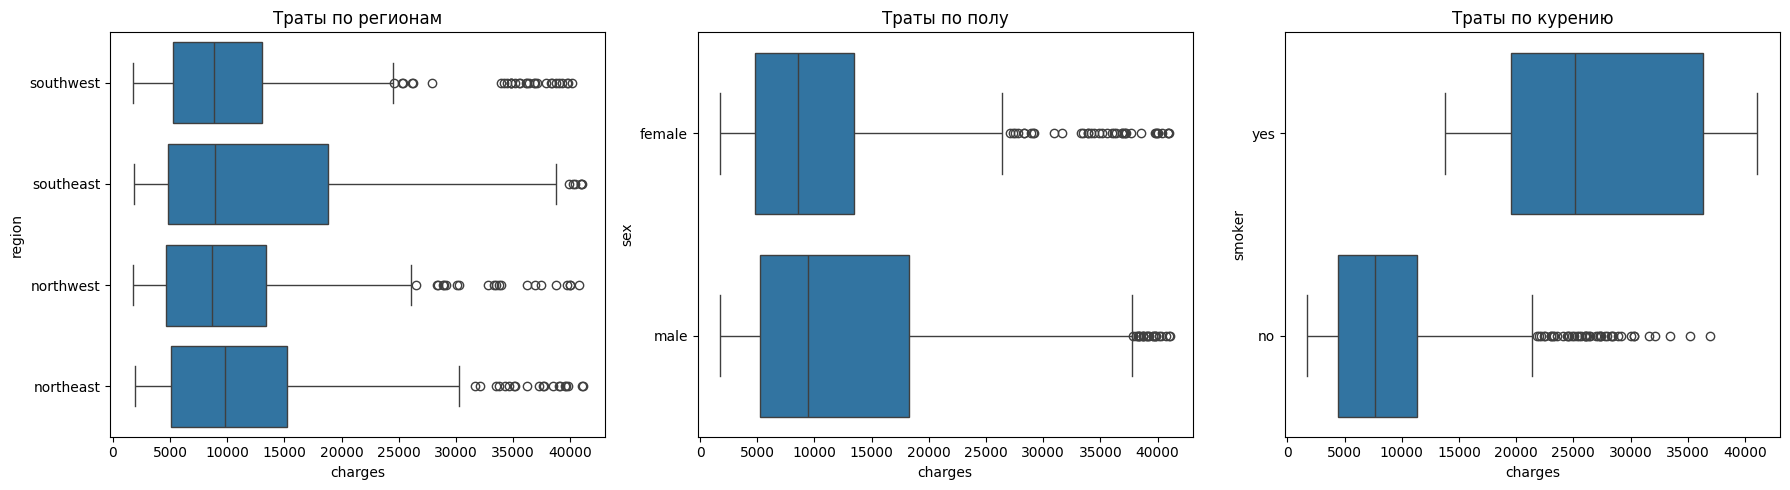

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y="region", x="charges", data=df_no_outliers, ax=axes[0])
axes[0].set_title("Траты по регионам")

sns.boxplot(y="sex", x="charges", data=df_no_outliers, ax=axes[1])
axes[1].set_title("Траты по полу")

sns.boxplot(y="smoker", x="charges", data=df_no_outliers, ax=axes[2])
axes[2].set_title("Траты по курению")

plt.tight_layout()
plt.show()
# Полностью аналогично блоку 9,
# но вместо df используется df_no_outliers (данные без выбросов)

In [41]:
Result_model

,Model,MAE,RMSE,R2
0,Lasso,4195.228376,6052.947090,0.754540
0,Random Forest,2516.681492,4488.845095,0.865006
0,CatBoostRegressor 1ver,2449.579590,4217.580011,0.878683
0,CatBoostRegressor 2ver,2508.630884,4255.325794,0.876502
0,CatBoostRegressor 3ver,2199.168566,4179.891909,0.887461
0,CatBoostRegressor 4ver,2318.117022,4052.681194,0.892136
